<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/HAR_QTFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
from google.colab import userdata
import sys
from google.colab import drive
import scipy.stats as stats
# from arch import arch_model
# from arch.univariate import ConstantMean, GARCH, StudentsT, FIGARCH
data_futures = pd.read_csv(userdata.get('data_path'))

In [92]:
# 1. Parse date and filter relevant contracts
data = data_futures.copy()
data["date"] = pd.to_datetime(data["date"])
data = data[data["symbol"].isin(["ES", "CL", "C", "GC", "NG"])].sort_values(
    ["symbol", "date"]
)

# 2. Daily percentage log returns
data["ret"] = data.groupby("symbol")["close_price"].transform(
    lambda x: np.log(x / x.shift(1)) * 100
)

# 3. Realized Volatility metrics & Multi-Horizon Rolling Windows
# (Grouping by symbol prevents data leakage across assets)
data["log_rv5"] = np.log(data["rv5"])
data["rv5_scaled"] = data["rv5"] * 10000

data["log_rv5_w"] = data.groupby("symbol")["log_rv5"].transform(
    lambda s: s.rolling(window=5).mean()
)
data["log_rv5_m"] = data.groupby("symbol")["log_rv5"].transform(
    lambda s: s.rolling(window=22).mean()
)

# 4. Pivot into wide DataFrame
df = data.pivot(
    index="date",
    columns="symbol",
    values=["close_price", "ret", "log_rv5", "rv5", "rv5_scaled", "log_rv5_w", "log_rv5_m"],
)
df.columns = [f"{col}_{sym}" for col, sym in df.columns]
df = df.dropna().copy()

In [84]:
# 1. Drive sicherstellen
drive.mount("/content/drive")

# 2. Ordnerpfad hinzufügen
folder_path = "/content/drive/MyDrive/Colab Notebooks"
if folder_path not in sys.path:
  sys.path.insert(0, folder_path)

# 3. Den genauen Dateinamen der .py-Datei verwenden (alles Kleinbuchstaben)
import group_project_qtfe_functions as gf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "ret" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
ret_C,-67.0871,0.0000e+00,0.0657,0.1,Stationary
ret_CL,-10.5924,6.4755e-19,0.0416,0.1,Stationary
ret_ES,-14.8572,1.7409e-27,0.0225,0.1,Stationary
ret_GC,-65.6566,0.0000e+00,0.3397,0.1,Stationary
ret_NG,-68.6773,0.0000e+00,0.0285,0.1,Stationary


In [88]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "log" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
log_rv5_C,-6.7954,2.3085e-09,1.0955,0.0100,Contradictory / Structural Break
log_rv5_CL,-4.9313,3.0296e-05,1.4041,0.0100,Contradictory / Structural Break
log_rv5_ES,-6.1309,8.4060e-08,0.3686,0.0907,Stationary
log_rv5_GC,-5.6447,1.0178e-06,0.8071,0.0100,Contradictory / Structural Break
log_rv5_NG,-4.4241,2.6900e-04,3.2578,0.0100,Contradictory / Structural Break
log_rv5_w_C,-5.3145,5.1092e-06,1.0602,0.0100,Contradictory / Structural Break
log_rv5_w_CL,-4.8405,4.5463e-05,1.4170,0.0100,Contradictory / Structural Break
log_rv5_w_ES,-5.6651,9.1896e-07,0.3582,0.0952,Stationary
log_rv5_w_GC,-4.9771,2.4633e-05,0.7824,0.0100,Contradictory / Structural Break


IndexError: index 5 is out of bounds for axis 0 with size 5

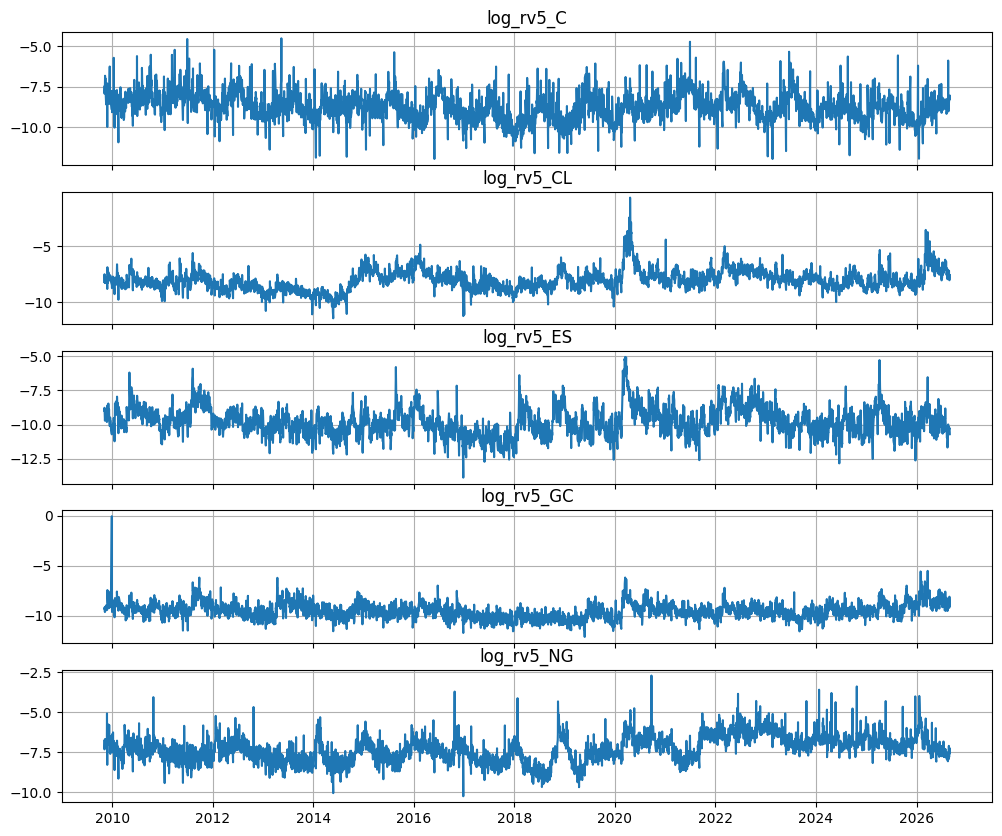

In [93]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
columns_to_plot = [col for col in df.columns if "log_rv5_" in col]

for i, col in enumerate(columns_to_plot):
    axes[i].plot(df[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [52]:
def fit_har_x(
    df_wide,
    target="ES",
    exog_symbols=None,
    metric="log_rv5",
    include_exog_horizons=False,
    hac_lags=22,
):
    """Fits an OLS HAR or HAR-X model with Newey-West standard errors.

    Parameters:
    -----------
    df_wide : pd.DataFrame
        Clean wide DataFrame aligned by date.
    target : str
        Target asset symbol (e.g. 'ES').
    exog_symbols : list of str, optional
        List of exogenous assets (e.g. ['CL'], ['CL', 'C'], or ['CL', 'GC', 'NG']).
    metric : str
        Prefix for realized volatility metric (e.g. 'log_rv5' or 'rk_scaled').
    include_exog_horizons : bool
        If False: includes only daily lag-1 of exog (X_{t-1}).
        If True: includes daily, weekly, and monthly components for each exog asset.
    hac_lags : int
        Newey-West truncation lag parameter.
    """
    if exog_symbols is None:
        exog_symbols = []

    # 1. Target: tomorrow's realized volatility (t+1)
    y_target = df_wide[f"{metric}_{target}"].shift(-1)

    # 2. Endogenous HAR components for target asset (at day t)
    X_dict = {
        f"{target}_d": df_wide[f"{metric}_{target}"],
        f"{target}_w": df_wide[f"{metric}_w_{target}"],
        f"{target}_m": df_wide[f"{metric}_m_{target}"],
    }

    # 3. Add Exogenous Regressors
    for sym in exog_symbols:
        if include_exog_horizons:
            # Include multi-horizon components: daily, weekly, monthly
            X_dict[f"{sym}_d"] = df_wide[f"{metric}_{sym}"]
            X_dict[f"{sym}_w"] = df_wide[f"{metric}_w_{sym}"]
            X_dict[f"{sym}_m"] = df_wide[f"{metric}_m_{sym}"]
        else:
            # Standard specification: single 1-day lagged spillover
            X_dict[f"{sym}_d"] = df_wide[f"{metric}_{sym}"]

    # 4. Construct design matrix & align sample
    design_df = pd.DataFrame(X_dict)
    design_df["target_t1"] = y_target
    design_df = design_df.dropna()

    y = design_df["target_t1"]
    X = sm.add_constant(design_df.drop(columns=["target_t1"]))

    # 5. Fit OLS with HAC standard errors
    model = sm.OLS(y, X)
    results = model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

    return results

In [94]:
model_es_solo = fit_har_x(df, target="ES")
model_har_oil  = fit_har_x(df, target="ES", exog_symbols=["CL"], include_exog_horizons=True)
model_har_corn = fit_har_x(df, target="ES", exog_symbols=["C"], include_exog_horizons=True)
model_har_both = fit_har_x(df, target="ES", exog_symbols=["CL", "C"], include_exog_horizons=True)
model_har_all  = fit_har_x(df, target="ES", exog_symbols=["CL", "C", "GC", "NG"], include_exog_horizons=True)

# 2. Build the comparison table
models = {
    "Baseline HAR": model_es_solo,
    "HAR-X (Oil)": model_har_oil,
    "HAR-X (Corn)": model_har_corn,
    "HAR-X (Oil + Corn)": model_har_both,
    "HAR-X (All 4)": model_har_all
}

summary_table = pd.DataFrame({
    "R²": [m.rsquared for m in models.values()],
    "Adj. R²": [m.rsquared_adj for m in models.values()],
    "AIC": [m.aic for m in models.values()],
    "BIC": [m.bic for m in models.values()]
}, index=models.keys())

print(summary_table.round(4))

                        R²  Adj. R²        AIC        BIC
Baseline HAR        0.6963   0.6961  7284.7925  7310.2505
HAR-X (Oil)         0.6965   0.6961  7287.9551  7332.5066
HAR-X (Corn)        0.6966   0.6962  7286.5559  7331.1075
HAR-X (Oil + Corn)  0.6969   0.6963  7288.5882  7352.2333
HAR-X (All 4)       0.6984   0.6973  7279.4583  7381.2904


In [95]:
model_har_all.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              target_t1   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     594.5
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:26:15   Log-Likelihood:                -3623.7
No. Observations:                4292   AIC:                             7279.
Df Residuals:                    4276   BIC:                             7381.
Df Model:                          15                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7311      0.168     -4.353      0.000      -1.060      -0.402
ES_d           0.5625      0.025     22.468      0.000       0.513       0.612
ES_w           0.2639      0.032      8.317      0.000       0.202       0.326
ES_m           0.0973      0.024      4.059      0.000       0.050       0.144
CL_d           0.0697      0.028      2.477      0.013       0.015       0.125
CL_w          -0.0644      0.039     -1.631      0.103      -0.142       0.013
CL_m          -0.0092      0.030     -0.306      0.759      -0.068       0.050
C_d           -0.0287      0.016     -1.778      0.075      -0.060       0.003
C_w            0.0107      0.033      0.328      0.743      -0.053       0.074
C_m            0.0137      0.033      0.411      0.681      -0.052       0.079
GC_d          -0.0668      0.027     -2.501      0.012      -0.119      -0.014
GC_w           0.0188      0.040      0.467      0.640      -0.060       0.098
GC_m           0.0339      0.036      0.940      0.347      -0.037       0.105
NG_d          -0.0312      0.023     -1.334      0.182      -0.077       0.015
NG_w          -0.0176      0.039     -0.452      0.651      -0.094       0.059
NG_m           0.0780      0.037      2.113      0.035       0.006       0.150
==============================================================================
Omnibus:                      181.559   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              423.595
Skew:                           0.248   Prob(JB):                     1.04e-92
Kurtosis:                       4.457   Cond. No.                         722.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 22 lags and without small sample correction
"""

In [55]:
def plot_har_residual_diagnostics(
    model_results, date_index=None, model_name="HAR-RV (ES)", lags=20, bins=70
):
    """Plots a 4-panel residual diagnostic grid for an OLS/HAR regression model."""
    # 1. Extract 1D residual series
    resid = model_results.resid

    # Attach proper date index if supplied (dropped last row due to t+1 forecast)
    if date_index is not None:
        resid = pd.Series(resid.values, index=date_index[: len(resid)])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- Panel 1: Residuals Over Time ---
    axes[0, 0].plot(
        resid.index, resid.values, color="#1f77b4", lw=0.8, alpha=0.85
    )
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.9)
    axes[0, 0].set_title(
        f"Residuals Over Time: {model_name}", fontweight="bold"
    )
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].grid(True, alpha=0.3)

    # --- Panel 2: Density vs Theoretical Normal ---
    axes[0, 1].hist(
        resid, bins=bins, density=True, alpha=0.55, color="#2ca02c", edgecolor="none"
    )
    mu, std = stats.norm.fit(resid)
    xmin, xmax = axes[0, 1].get_xlim()
    x_pdf = np.linspace(xmin, xmax, 500)
    kurt = stats.kurtosis(resid, fisher=False)  # Pearson kurtosis (Normal = 3.0)
    skew = stats.skew(resid)

    axes[0, 1].plot(
        x_pdf,
        stats.norm.pdf(x_pdf, mu, std),
        "r--",
        lw=2,
        label=rf"Normal ($\mu={mu:.3f},\ \sigma={std:.3f}$)",
    )
    axes[0, 1].set_title(
        f"Empirical vs. Normal (Kurtosis: {kurt:.1f}, Skew: {skew:.2f})",
        fontweight="bold",
    )
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # --- Panel 3: Q-Q Plot (Heavy Tails) ---
    sm.qqplot(resid, line="45", fit=True, ax=axes[1, 0], color="#1f77b4", alpha=0.5)
    axes[1, 0].set_title("Normal Q-Q Plot (Tail Extremity)", fontweight="bold")
    axes[1, 0].grid(True, alpha=0.3)

    # --- Panel 4: Autocorrelation Function (ACF) ---
    sm.graphics.tsa.plot_acf(resid, lags=lags, ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title(
        f"Residual ACF (Up to {lags} Lags)", fontweight="bold"
    )
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylabel("Autocorrelation")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

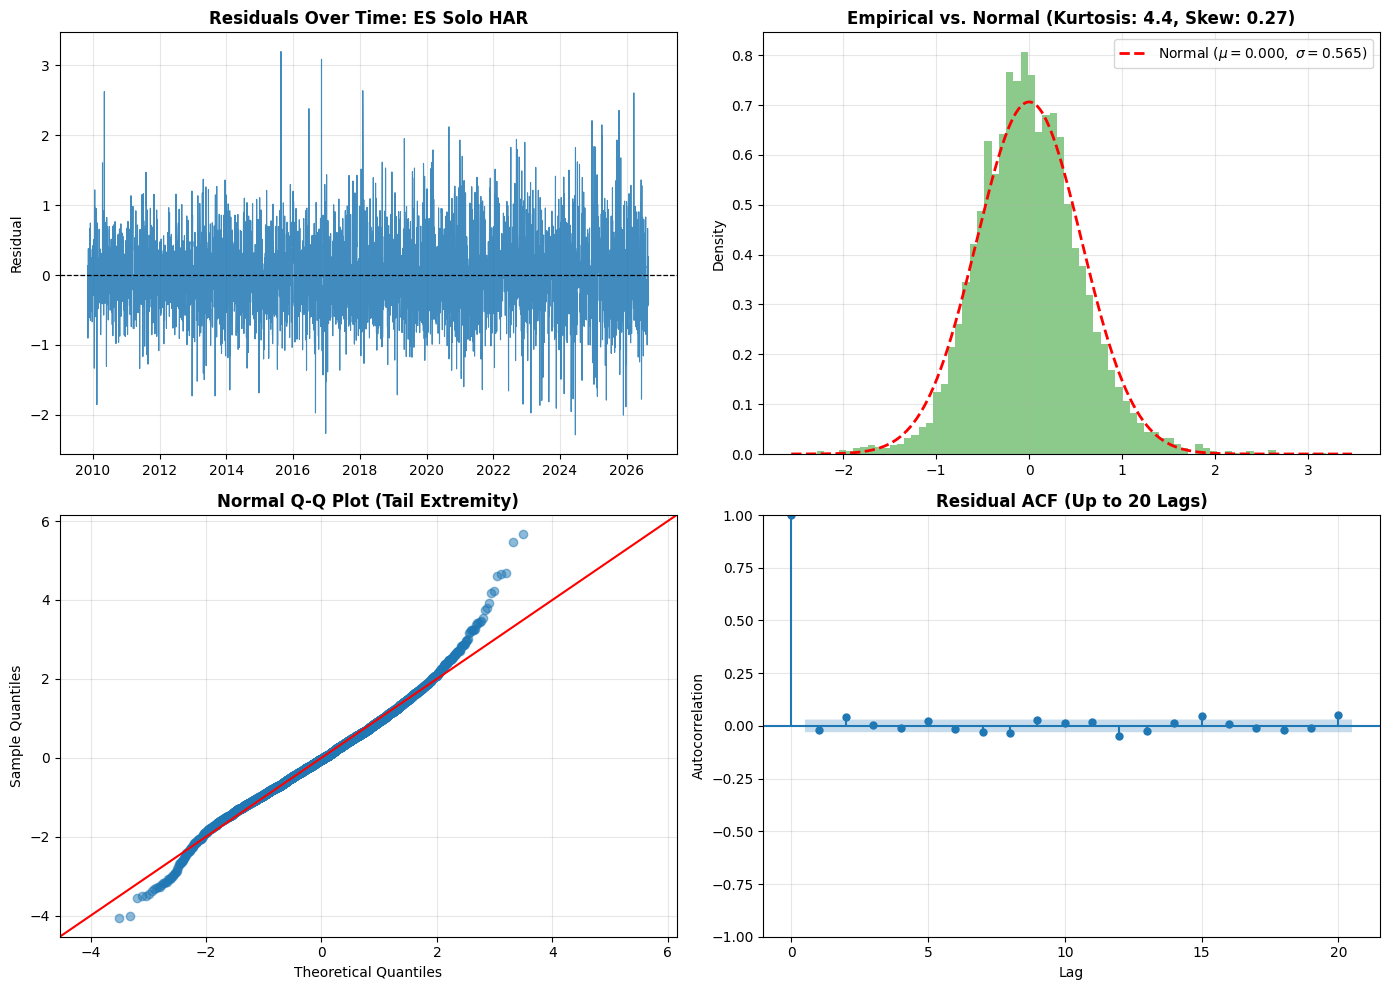

In [75]:
plot_har_residual_diagnostics(
    model_har_all, date_index=df.index[:-1], model_name="ES Solo HAR"
)

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm


def forecast_har_x(
    df_wide,
    target="ES",
    exog_symbols=None,
    metric="log_rv5",
    exog_lags=1,
    forecast_horizon=500,
    alpha=0.05,
    rolling=False,
):
    """Generates out-of-sample 1-step-ahead forecasts with prediction intervals.

    Parameters:
    -----------
    df_wide : pd.DataFrame
        Clean wide DataFrame aligned by date.
    target : str
        Target asset symbol (e.g., 'ES').
    exog_symbols : list of str, optional
        List of exogenous assets (e.g., ['CL'], ['CL', 'GC']).
    metric : str
        Realized volatility metric prefix (e.g., 'log_rv5').
    exog_lags : int
        Number of lags to include for each exogenous regressor (default: 1).
    forecast_horizon : int
        Number of out-of-sample trading days to predict (e.g., 500).
    alpha : float
        Significance level for prediction intervals (0.05 = 95% confidence).
    rolling : bool
        If False, uses expanding estimation window; if True, uses fixed-length rolling window.

    Returns:
    --------
    results_df : pd.DataFrame
        DataFrame with Actuals, Forecasts, Lower/Upper Intervals, and Residuals.
    metrics : dict
        RMSE, MAE, QLIKE, Empirical Coverage Rate, R2_OOS, and R2_Pred_Corr.
    """
    if exog_symbols is None:
        exog_symbols = []

    # 1. Construct Target Series (Tomorrow's RV: t+1)
    y_target = df_wide[f"{metric}_{target}"].shift(-1)

    # 2. Build Design Matrix (Information available at day t)
    # Endogenous Corsi components for target
    X_dict = {
        f"{target}_d": df_wide[f"{metric}_{target}"],
        f"{target}_w": df_wide[f"{metric}_w_{target}"],
        f"{target}_m": df_wide[f"{metric}_m_{target}"],
    }

    # Exogenous components with user-selected number of lags
    for sym in exog_symbols:
        for lag in range(1, exog_lags + 1):
            X_dict[f"{sym}_lag{lag}"] = df_wide[f"{metric}_{sym}"].shift(lag - 1)

    design_df = pd.DataFrame(X_dict)
    design_df["target_t1"] = y_target
    design_df = design_df.dropna()

    T_total = len(design_df)
    if forecast_horizon >= T_total:
        raise ValueError(
            f"forecast_horizon ({forecast_horizon}) must be smaller than sample length ({T_total})."
        )

    # In-sample vs. Out-of-sample split boundary
    train_size = T_total - forecast_horizon

    y_full = design_df["target_t1"]
    X_full = sm.add_constant(design_df.drop(columns=["target_t1"]))

    forecasts = []
    actuals = []
    lower_bounds = []
    upper_bounds = []
    benchmark_preds = []  # Prevailing historical mean up to day t
    dates = []

    # Critical value from standard normal for (1 - alpha) interval
    z_crit = stats.norm.ppf(1 - alpha / 2)

    # 3. Recursive Out-of-Sample Estimation Loop
    for i in range(forecast_horizon):
        t_idx = train_size + i

        # Expanding vs Rolling window selection
        if rolling:
            X_train = X_full.iloc[i:t_idx]
            y_train = y_full.iloc[i:t_idx]
        else:
            X_train = X_full.iloc[:t_idx]
            y_train = y_full.iloc[:t_idx]

        # Forecast vector at time t (to forecast t+1)
        x_pred = X_full.iloc[[t_idx]]
        actual_val = y_full.iloc[t_idx]
        pred_date = design_df.index[t_idx]

        # Record unconditional benchmark (prevailing historical mean up to t)
        benchmark_preds.append(y_train.mean())

        # Fit model on training slice
        model = sm.OLS(y_train, X_train).fit()

        # Point forecast
        y_hat = float(model.predict(x_pred).iloc[0])

        # Analytical Prediction Interval Error:
        # SE_pred = s * sqrt(1 + x_0 * (X'X)^(-1) * x_0')
        s2 = model.mse_resid
        X_mat = X_train.to_numpy()
        x_vec = x_pred.to_numpy().reshape(-1, 1)

        try:
            XtX_inv = np.linalg.inv(X_mat.T @ X_mat)
            leverage = float((x_vec.T @ XtX_inv @ x_vec).item())
        except np.linalg.LinAlgError:
            leverage = 0.0

        se_pred = np.sqrt(s2 * (1.0 + leverage))

        # Interval bounds
        lower = y_hat - z_crit * se_pred
        upper = y_hat + z_crit * se_pred

        forecasts.append(y_hat)
        actuals.append(actual_val)
        lower_bounds.append(lower)
        upper_bounds.append(upper)
        dates.append(pred_date)

    # 4. Compile Forecast Results
    res_df = pd.DataFrame(
        {
            "Actual": actuals,
            "Forecast": forecasts,
            "Benchmark_Mean": benchmark_preds,
            "Lower_CI": lower_bounds,
            "Upper_CI": upper_bounds,
            "Error": np.array(actuals) - np.array(forecasts),
        },
        index=pd.to_datetime(dates),
    )

    # 5. Evaluate Performance Metrics
    actual_arr = np.array(actuals)
    forecast_arr = np.array(forecasts)
    bench_arr = np.array(benchmark_preds)

    # Errors
    model_mse = np.mean((actual_arr - forecast_arr) ** 2)
    bench_mse = np.mean((actual_arr - bench_arr) ** 2)

    rmse = np.sqrt(model_mse)
    mae = np.mean(np.abs(res_df["Error"]))

    # Out-of-Sample Campbell-Thompson R²
    r2_oos = 1.0 - (model_mse / bench_mse)

    # Squared Correlation R² (Mincer-Zarnowitz style)
    corr_matrix = np.corrcoef(actual_arr, forecast_arr)
    r2_corr = corr_matrix[0, 1] ** 2

    # Empirical coverage: % of actuals within prediction bands
    coverage = np.mean(
        (res_df["Actual"] >= res_df["Lower_CI"])
        & (res_df["Actual"] <= res_df["Upper_CI"])
    )

    # QLIKE Loss Function
    diff = res_df["Actual"] - res_df["Forecast"]
    qlike = np.mean(np.exp(diff) - diff - 1)

    eval_metrics = {
        "RMSE": round(float(rmse), 4),
        "MAE": round(float(mae), 4),
        "QLIKE": round(float(qlike), 4),
        "Coverage_Rate": f"{coverage * 100:.2f}%",
        "R2_OOS": f"{r2_oos * 100:.2f}%",
        "R2_Pred_Corr": f"{r2_corr * 100:.2f}%",
    }

    return res_df, eval_metrics

In [81]:
forecast_har_x(df, exog_symbols=['C', 'CL', 'GC', 'NG'])

(               Actual   Forecast  Benchmark_Mean   Lower_CI  Upper_CI  \
 2024-09-13 -10.176995  -9.999707       -9.770885 -11.080930 -8.918483   
 2024-09-16  -9.955232  -9.943803       -9.770992 -11.025008 -8.862598   
 2024-09-17  -8.690088  -9.850322       -9.771040 -10.931079 -8.769565   
 2024-09-18  -9.888469  -9.166808       -9.770756 -10.248831 -8.084786   
 2024-09-19 -10.434441  -9.825497       -9.770787 -10.906934 -8.744061   
 ...               ...        ...             ...        ...       ...   
 2026-08-24 -10.641644 -10.421421       -9.778533 -11.529470 -9.313372   
 2026-08-25 -10.204191 -10.493469       -9.778734 -11.601381 -9.385557   
 2026-08-26 -10.326720 -10.269644       -9.778834 -11.377075 -9.162212   
 2026-08-27 -10.273012 -10.345563       -9.778961 -11.452823 -9.238302   
 2026-08-28 -10.700392 -10.339354       -9.779076 -11.447036 -9.231671   
 
                Error  
 2024-09-13 -0.177288  
 2024-09-16 -0.011429  
 2024-09-17  1.160234  
 2024-09-18 -0